In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Input, Concatenate
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import joblib
import os
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

In [27]:
class RealtimeTrafficPredictor:
    
    
    # Initialize the realtime traffic predictor
    def __init__(self, data_path='../data/gold', model_path='../src/models/'):
        self.data_path = data_path
        self.model_path = model_path
        self.lookback = 6 # 30 minutes (5- minute intervals)
        self.forecast_steps = 1 #Predict next 5 minutes
        
        # Create Directories if they dont exist
        os.makedirs(self.model_path, exist_ok=True)
        os.makedirs('plots', exist_ok=True)
        
        self.scaler = MinMaxScaler()
        self.models = {}
    
    
    #load Parquet data from te gold folder
    def load_data(self, parquet_file):
        file_path = os.path.join(self.data_path, parquet_file)
        df = pd.read_parquet(file_path)
        print(f"loaded {len(df)} records from {parquet_file}")
        return df
    
    
    # Preprocess the real- time data
    def preprocess_data(self, df, road_id=None):
        df['window_start'] = pd.to_datetime(df['window_start'])
        df['wiindow_end'] = pd.to_datetime(df['window_end'])
        
        #filter timestamps if specified
        if road_id:
            df = df[df['road_id'] == road_id].copy()
            print(f'Filtered to road_id: {road_id}, {len(df)} records')
        
        #Sort by timestamps   
        df = df.sort_values('window_start').reset_index(drop=True)
        
        
        # Extract time features
        df['hour'] = df['window_start'].dt.hour
        df['minute'] = df['window_start'].dt.minute
        df['day_of_week'] = df['window_start'].dt.dayofweek
        df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
        df['is_rush_hour'] = ((df['hour'].between(7, 10)) | (df['hour'].between(17, 20))).astype(int)
        
        # Calculate time based features
        df['time_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
        df['time_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
        df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
        df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
        
        return df
    
    
    # Create additional features for prediction
    def create_features(self, df):
        # Speed Change rate
        df['speed_change'] = df['avg_speed'].diff()
        df['congestion_change'] = df['avg_congestion_index'].diff()
        
        #Rolling statistics (past 3 and 6 periods)
        for window in[3, 6]:
            df[f'speed_rolling_mean_{window}'] = df['avg_speed'].rolling(window=window, min_periods=1).mean()
            df[f'speed_rolling_std_{window}'] = df['avg_speed'].rolling(window=window, min_periods=1).std()
            df[f'congestion_rolling_mean_{window}'] = df['avg_congestion_index'].rolling(window=window, min_periods=1).mean()
            df[f'congestion_rolling_std_{window}'] = df['avg_congestion_index'].rolling(window=window, min_periods=1).std()
            
        # Fill NaN Values
        df = df.fillna(method='bfill').fillna(method='ffill')
        
        return df
    
    
    # Create sequences for time seris prediction
    def create_sequences(self, data, feature_cols, target_col):
        X, y = [], []
        
        for i in range(len(data) - self.lookback):
            X.append(data[feature_cols].iloc[i:i+self.lookback].values)
            y.append(data[target_col].iloc[i+self.lookback])
            
        return np.array(X), np.array(y)
    
    
    # Prepare data for training
    def prepare_data(self, df, test_size=0.2):
        # Define features columns
        feature_cols = ['avg_speed', 'avg_congestion_index', 'hour', 'minute', 'day_of_week', 'is_weekend', 'is_rush_hour', 'time_sin', 'time_cos','day_sin', 'day_cos', 'speed_change', 'congestion_change']
        
        # Add rolling features
        rolling_cols = [col for col in df.columns if 'rolling' in col]
        feature_cols.extend(rolling_cols)
        
        # Ensure all feature columns exist
        feature_cols = [col for col in feature_cols if col in df.columns]
        
        target_col = 'avg_congestion_index'
        
        #Scale the features 
        df_scaled = df.copy()
        df_scaled[feature_cols] = self.scaler.fit_transform(df[feature_cols])
        
        # Create sequences
        X, y = self.create_sequences(df_scaled, feature_cols, target_col)
        
        #Split into train and test
        split_idx = int(len(X) * (1 - test_size))
        X_train, X_test = X[:split_idx], X[split_idx:]
        y_train, y_test = y[:split_idx], y[split_idx:]
        
        print(f"\nData Prepared: ")
        print(f"Training samples: {len(X_train)}")
        print(f"Testing samples: {len(X_test)}")
        print(f"Features: {len(feature_cols)}")
        print(f"Sequence length: {self.lookback}")
        
        return X_train, X_test, y_train, y_test, feature_cols
    
    
    
    #build LSTM Model
    def build_lstm_model(self, input_shape):
        model = Sequential([
            LSTM(64, return_sequences=True, input_shape=input_shape),
            Dropout(0.2),
            LSTM(32, return_sequences=False),
            Dropout(0.2),
            Dense(16, activation='relu'),
            Dense(1)
        ])
        
        model.compile(optimizer='adam', loss='mse', metrics=['mae'])
        return model
    
    
    # Building the GRU model
    def build_gru_model(self, input_shape):
        model = Sequential([
            GRU(64, return_sequences=True, input_shape=input_shape),
            Dropout(0.2),
            GRU(32, return_sequences=False),
            Dropout(0.2),
            Dense(16, activation='relu'),
            Dense(1)
        ])
        
        model.compile(optimizer='adam', loss='mse', metrics=['mae'])
        return model
    
    
    #Building the LSTM+GRU hybrid model
    def build_lstm_gru_model(self, input_shape):
        model = Sequential([
            LSTM(64, return_sequences=True, input_shape=input_shape),
            Dropout(0.2),
            GRU(32, return_sequences=False),
            Dropout(0.2),
            Dense(16, activation='relu'),
            Dense(1)
        ])
        
        model.compile(optimizer='adam', loss='mse', metrics=['mae'])
        return model
    
    
    # Building the GRU+LSTM hybrid model
    def build_gru_lstm_model(self, input_shape):
        model = Sequential([
            GRU(64, return_sequences=True, input_shape=input_shape),
            Dropout(0.2),
            LSTM(32, return_sequences=False),
            Dropout(0.2),
            Dense(16, activation='relu'),
            Dense(1)
        ])
        
        model.compile(optimizer='adam', loss='mse', metrics=['mae'])
        return model
    
    
    # Train deep learning models (LSTM, GRU, etc.)
    def train_deep_learning_model(self, model, model_name, X_train, X_test, y_train, y_test):
        print(f"\n{'='*60}")
        print(f"Training {model_name} Model")
        print('='* 60)
        
        #Callbacks
        early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
        checkpoint = ModelCheckpoint(
            os.path.join(self.model_path, f'{model_name.lower()}_best.keras'),
            monitor = 'val_loss',
            save_best_only=True
        )
        
        #Train model
        history = model.fit(
            X_train, y_train,
            validation_data=(X_test, y_test),
            epochs=100,
            batch_size=32,
            callbacks=[early_stop, checkpoint],
            verbose=1
        )
        
        # Make predictions
        y_pred_train = model.predict(X_train).flatten()
        y_pred_test = model.predict(X_test).flatten()
        
        #Calculate metrics
        train_mae = mean_absolute_error(y_train, y_pred_train)
        train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
        test_mae = mean_absolute_error(y_test, y_pred_test)
        test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
        test_r2 = r2_score(y_test, y_pred_test)
        
        print(f"\n{model_name} Results: ")
        print(f"Train MAE: {train_mae:.4f}, Train RMSE: {train_rmse:.4f}")
        print(f"Test MAE: {test_mae:.4f}, Test RMSE: {test_rmse:.4f}, Test R²:{test_r2:.4f}")
        
        # Save model
        model.save(os.path.join(self.model_path, f'{model_name.lower()}.keras'))
        print(f"Model saved to {self.model_path}/{model_name.lower()}.keras")
        
        return model, history, y_pred_test
    
    
    # Train Random Forest Regressor
    def train_random_forest(self, X_train, X_test, y_train, y_test):
        print(f"\n{'='*60}")
        print("Training Random Forest Model")
        print('='*60)
        
        #Reshape data for Random Forest (flastten sequences)
        X_train_rf = X_train.reshape(X_train.shape[0], -1)
        X_test_rf = X_test.reshape(X_test.shape[0], -1)
        
        #Train model
        model = RandomForestRegressor(
            n_estimators=200,
            max_depth=20,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        )
        
        model.fit(X_train_rf, y_train)
        
        # Make Predictions
        y_pred_train = model.predict(X_train_rf)
        y_pred_test = model.predict(X_test_rf)
        
        # Calculate metrics
        train_mae = mean_absolute_error(y_train, y_pred_train)
        train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
        test_mae = mean_absolute_error(y_test, y_pred_test)
        test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
        test_r2 = r2_score(y_test, y_pred_test)
        
        print(f"\nRandom Forest Results: ")
        print(f"Train MAE: {train_mae:.4f}, Train RMSE: {train_rmse:.4f}")
        print(f"Test MAE: {test_mae:.4f}, Test RMSE: {test_rmse:.4f}, Test R²: {test_r2:.4f}")
        
        # Save model
        joblib.dump(model, os.path.join(self.model_path, 'random_forest.joblib'))
        print(f"Model saved to {self.model_path}/random_forest.joblib")
        
        return model, y_pred_test
    
    
    # Train all models and save them
    def train_all_models(self, df, road_id=None):
        df = self.preprocess_data(df, road_id)
        df = self.create_features(df)
        
        #Prepare data
        X_train, X_test, y_train, y_test, feature_cols = self.prepare_data(df)
        
        # Store results
        results = {}
        predictions = {}
        
        # Train LSTM
        lstm_model = self.build_lstm_model((X_train.shape[1], X_train.shape[2]))
        lstm_trained, lstm_history, lstm_pred = self.train_deep_learning_model(
            lstm_model, 'LSTM', X_train, X_test, y_train, y_test
        )
        results['LSTM'] = lstm_history
        predictions['LSTM'] = lstm_pred
        self.models['LSTM'] = lstm_trained
        
        # Train GRU
        gru_model = self.build_gru_model((X_train.shape[1], X_train.shape[2]))
        gru_trained, gru_history, gru_pred = self.train_deep_learning_model(
            gru_model, 'GRU', X_train, X_test, y_train, y_test
        )
        results['GRU'] = gru_history
        predictions['GRU'] = gru_pred
        self.models['GRU'] = gru_trained
        
        # Train LSTM+GRU
        lstm_gru_model = self.build_lstm_gru_model((X_train.shape[1], X_train.shape[2]))
        lstm_gru_trained, lstm_gru_history, lstm_gru_pred = self.train_deep_learning_model(
            lstm_gru_model, 'LSTM_GRU', X_train, X_test, y_train, y_test
        )
        results['LSTM_GRU'] = lstm_gru_history
        predictions['LSTM_GRU'] = lstm_gru_pred
        self.models['LSTM_GRU'] = lstm_gru_trained
        
        # Train GRU+LSTM
        gru_lstm_model = self.build_gru_lstm_model((X_train.shape[1], X_train.shape[2]))
        gru_lstm_trained, gru_lstm_history, gru_lstm_pred = self.train_deep_learning_model(
            gru_lstm_model, 'GRU_LSTM', X_train, X_test, y_train, y_test
        )
        results['GRU_LSTM'] = gru_lstm_history
        predictions['GRU_LSTM'] = gru_lstm_pred
        self.models['GRU_LSTM'] = gru_lstm_trained
        
        # Train Random Forest
        rf_trained, rf_pred = self.train_random_forest(X_train, X_test, y_train, y_test)
        predictions['Random_Forest'] = rf_pred
        self.models['Random_Forest'] = rf_trained
        
        #Save scaler
        joblib.dump(self.scaler, os.path.join(self.model_path, 'scaler.joblib'))
        
        # Plot results
        self.plot_predictions(y_test, predictions, df, road_id)
        
        return results, predictions
    
    
    # Plot actual vs predicted values
    def plot_predictions(self, y_test, predictions, df, road_id):
        fig, axes = plt.subplots(3, 2, figsize=(16, 12))
        fig.suptitle(f'Traffic Congestion predictions - Road: {road_id}', fontsize=16, fontweight='bold')
        
        axes = axes.flatten()
        
        # Get timestamps for test data
        test_start_idx = len(df) - len(y_test)
        timestamps = df['window_start'].iloc[test_start_idx:].values
        
        colors = {
            'LSTM': '#1f77b4',
            'GRU': '#ff7f0e',
            'LSTM_GRU': '#2ca02c',
            'GRU_LSTM': '#d62728',
            'Random_Forest': '#9467bd'
        }
        
        for idx, (model_name, y_pred) in enumerate(predictions.items()):
            ax = axes[idx]
            
            # Plot Actual data (solid line)
            ax.plot(timestamps, y_test, label='Actual', color='black', linewidth=2, alpha=0.8, marker='o', markersize=3)
            
            # Plot predicted data
            ax.plot(timestamps, y_pred, label='Predicted', color=colors[model_name], linewidth=2, alpha=0.5, linestyle='--', marker='s', markersize=3)
            
            # Calculate metrics for display
            mae = mean_absolute_error(y_test, y_pred)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            r2 = r2_score(y_test, y_pred)
            
            #Styling
            ax.set_title(f'{model_name}\nMAE: {mae:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f}',fontweight='bold', fontsize=11)
            ax.set_xlabel('Timestamp', fontsize=10)
            ax.set_ylabel('Congestion Index', fontsize=10)
            ax.legend(loc='upper left', fontsize=9)
            ax.grid(True, alpha=0.3, linestyle=':')
            ax.tick_params(axis='x', rotation=45, labelsize=8)
            
            # Add shaded area between actual and predicted
            ax.fill_between(timestamps, y_test, y_pred, alpha=0.2, color=colors[model_name])
        
        # Hide the last subplot if we have odd number of models
        if len(predictions) < 6:
            axes[-1].axis('off')
        
        plt.tight_layout()
        plot_path = os.path.join('plots', f'predictions_{road_id}_{datetime.now().strftime("%Y%m%d_%H%M%S")}.png')
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
        print(f"\nPlot saved to {plot_path}")
        plt.show()
    
    
    
    # Predict the next 5 minutes using trained model
    def predict_next_5min(self, df, road_id, model_name='LSTM'):
        # Load model if not in memory
        if model_name not in self.models:
            if model_name == 'Random_Forest':
                self.models[model_name] = joblib.load(
                    os.path.join(self.model_path, f'{model_name.lower()}.joblib')
                )
            else:
                self.models[model_name] = load_model(
                    os.path.join(self.model_path, f'{model_name.lower()}.keras')
                )
        
        # Load scaler
        self.scaler = joblib.load(os.path.join(self.model_path, 'scaler.joblib'))
        
        # Preprocess latest data
        df = self.preprocess_data(df, road_id)
        df = self.create_features(df)
        
        # Get last 30 minutes (6 intervals of 5 minutes)
        latest_data = df.tail(self.lookback).copy()
        
        if len(latest_data) < self.lookback:
            raise ValueError(f"Not enough data. Need at least {self.lookback} records (30 minutes)")
        
        # Define feature columns (same as training)
        feature_cols = ['avg_speed', 'avg_congestion_index', 'hour', 'minute', 
                       'day_of_week', 'is_weekend', 'is_rush_hour',
                       'time_sin', 'time_cos', 'day_sin', 'day_cos',
                       'speed_change', 'congestion_change']
        rolling_cols = [col for col in latest_data.columns if 'rolling' in col]
        feature_cols.extend(rolling_cols)
        feature_cols = [col for col in feature_cols if col in latest_data.columns]
        
        # Scale features
        latest_scaled = self.scaler.transform(latest_data[feature_cols])
        
        # Prepare input
        X_pred = latest_scaled.reshape(1, self.lookback, len(feature_cols))
        
        # Make prediction
        if model_name == 'Random_Forest':
            X_pred_rf = X_pred.reshape(1, -1)
            prediction = self.models[model_name].predict(X_pred_rf)[0]
        else:
            prediction = self.models[model_name].predict(X_pred)[0][0]
        
        # Get next timestamp
        last_timestamp = df['window_start'].iloc[-1]
        next_timestamp = last_timestamp + timedelta(minutes=5)
        
        result = {
            'road_id': road_id,
            'model': model_name,
            'predicted_timestamp': next_timestamp,
            'predicted_congestion_index': float(prediction),
            'current_congestion_index': float(df['avg_congestion_index'].iloc[-1]),
            'current_speed': float(df['avg_speed'].iloc[-1]),
            'last_update': last_timestamp
        }
        
        return result


Loading ../data/gold\part-00000-04de6f92-71d2-4420-aed3-c23f8993a960-c000.snappy.parquet ...
loaded 0 records from part-00000-04de6f92-71d2-4420-aed3-c23f8993a960-c000.snappy.parquet
Loading ../data/gold\part-00000-0d5abd52-31af-4395-a67e-6497ed06bd86-c000.snappy.parquet ...
loaded 0 records from part-00000-0d5abd52-31af-4395-a67e-6497ed06bd86-c000.snappy.parquet
Loading ../data/gold\part-00000-18da1c57-ac17-4e25-9e2b-10f7fc90d3e3-c000.snappy.parquet ...
loaded 0 records from part-00000-18da1c57-ac17-4e25-9e2b-10f7fc90d3e3-c000.snappy.parquet
Loading ../data/gold\part-00000-1e650835-519b-4fab-be69-1174b68c821e-c000.snappy.parquet ...
loaded 0 records from part-00000-1e650835-519b-4fab-be69-1174b68c821e-c000.snappy.parquet
Loading ../data/gold\part-00000-20af4529-f3b1-4eaa-aee6-8782a8958c6a-c000.snappy.parquet ...
loaded 0 records from part-00000-20af4529-f3b1-4eaa-aee6-8782a8958c6a-c000.snappy.parquet
Loading ../data/gold\part-00000-2251fef1-7551-44be-8e3c-74ea2a9e0574-c000.snappy.parq

loaded 1 records from part-00000-f895858d-34b6-4e91-aa6f-6fad4de77c5f-c000.snappy.parquet
Loading ../data/gold\part-00000-ffb98813-28a9-4453-8784-bef7a2180a9e-c000.snappy.parquet ...
loaded 0 records from part-00000-ffb98813-28a9-4453-8784-bef7a2180a9e-c000.snappy.parquet
Loading ../data/gold\part-00001-29e5e870-4480-45da-87f7-1334da977b76-c000.snappy.parquet ...
loaded 1 records from part-00001-29e5e870-4480-45da-87f7-1334da977b76-c000.snappy.parquet
Loading ../data/gold\part-00001-5d815170-92fa-4e6d-83da-61550f6d0e37-c000.snappy.parquet ...
loaded 1 records from part-00001-5d815170-92fa-4e6d-83da-61550f6d0e37-c000.snappy.parquet
Loading ../data/gold\part-00001-ffb98813-28a9-4453-8784-bef7a2180a9e-c000.snappy.parquet ...
loaded 1 records from part-00001-ffb98813-28a9-4453-8784-bef7a2180a9e-c000.snappy.parquet
Loading ../data/gold\part-00002-2a1a4088-5a2f-4fdd-a092-d8a17bc9cf63-c000.snappy.parquet ...
loaded 1 records from part-00002-2a1a4088-5a2f-4fdd-a092-d8a17bc9cf63-c000.snappy.par

loaded 1 records from part-00025-c6d9176a-59ce-4f44-a1ad-824aa8534182-c000.snappy.parquet
Loading ../data/gold\part-00025-cbc6060c-c866-42e9-9427-53c72a64f167-c000.snappy.parquet ...
loaded 2 records from part-00025-cbc6060c-c866-42e9-9427-53c72a64f167-c000.snappy.parquet
Loading ../data/gold\part-00025-dee9d070-cdd5-4185-9126-d106c44c2441-c000.snappy.parquet ...
loaded 1 records from part-00025-dee9d070-cdd5-4185-9126-d106c44c2441-c000.snappy.parquet
Loading ../data/gold\part-00025-ffb98813-28a9-4453-8784-bef7a2180a9e-c000.snappy.parquet ...
loaded 1 records from part-00025-ffb98813-28a9-4453-8784-bef7a2180a9e-c000.snappy.parquet
Loading ../data/gold\part-00026-2251fef1-7551-44be-8e3c-74ea2a9e0574-c000.snappy.parquet ...
loaded 1 records from part-00026-2251fef1-7551-44be-8e3c-74ea2a9e0574-c000.snappy.parquet
Loading ../data/gold\part-00026-235f4b9c-17d1-44d0-8863-df2741a07a39-c000.snappy.parquet ...
loaded 1 records from part-00026-235f4b9c-17d1-44d0-8863-df2741a07a39-c000.snappy.par

loaded 1 records from part-00052-2b4314c4-cc21-4aad-bf7c-f3d0258a3214-c000.snappy.parquet
Loading ../data/gold\part-00052-9c6e487c-2069-438a-8548-9dc85f1f56f6-c000.snappy.parquet ...
loaded 1 records from part-00052-9c6e487c-2069-438a-8548-9dc85f1f56f6-c000.snappy.parquet
Loading ../data/gold\part-00053-0d5abd52-31af-4395-a67e-6497ed06bd86-c000.snappy.parquet ...
loaded 1 records from part-00053-0d5abd52-31af-4395-a67e-6497ed06bd86-c000.snappy.parquet
Loading ../data/gold\part-00053-2a1a4088-5a2f-4fdd-a092-d8a17bc9cf63-c000.snappy.parquet ...
loaded 1 records from part-00053-2a1a4088-5a2f-4fdd-a092-d8a17bc9cf63-c000.snappy.parquet
Loading ../data/gold\part-00053-c6f2d818-c3ce-4c80-a51a-dcf6a89f362a-c000.snappy.parquet ...
loaded 1 records from part-00053-c6f2d818-c3ce-4c80-a51a-dcf6a89f362a-c000.snappy.parquet
Loading ../data/gold\part-00054-50cb1271-81f5-40c9-87bf-7cd19eed7a71-c000.snappy.parquet ...
loaded 1 records from part-00054-50cb1271-81f5-40c9-87bf-7cd19eed7a71-c000.snappy.par

loaded 1 records from part-00077-37db6a98-27aa-4ec7-8520-7b61bf1f3d7f-c000.snappy.parquet
Loading ../data/gold\part-00078-2b4314c4-cc21-4aad-bf7c-f3d0258a3214-c000.snappy.parquet ...
loaded 1 records from part-00078-2b4314c4-cc21-4aad-bf7c-f3d0258a3214-c000.snappy.parquet
Loading ../data/gold\part-00078-713307a8-e55c-49c1-b343-fc6f8226ac6b-c000.snappy.parquet ...
loaded 1 records from part-00078-713307a8-e55c-49c1-b343-fc6f8226ac6b-c000.snappy.parquet
Loading ../data/gold\part-00078-c6d9176a-59ce-4f44-a1ad-824aa8534182-c000.snappy.parquet ...
loaded 1 records from part-00078-c6d9176a-59ce-4f44-a1ad-824aa8534182-c000.snappy.parquet
Loading ../data/gold\part-00079-18da1c57-ac17-4e25-9e2b-10f7fc90d3e3-c000.snappy.parquet ...
loaded 1 records from part-00079-18da1c57-ac17-4e25-9e2b-10f7fc90d3e3-c000.snappy.parquet
Loading ../data/gold\part-00079-a34124e6-84d1-41ae-9d13-0eb9b6dfd272-c000.snappy.parquet ...
loaded 1 records from part-00079-a34124e6-84d1-41ae-9d13-0eb9b6dfd272-c000.snappy.par

...

loaded 1 records from part-00148-37db6a98-27aa-4ec7-8520-7b61bf1f3d7f-c000.snappy.parquet
Loading ../data/gold\part-00148-5abd4839-a915-4ea3-a69f-206bf248af14-c000.snappy.parquet ...
loaded 1 records from part-00148-5abd4839-a915-4ea3-a69f-206bf248af14-c000.snappy.parquet
Loading ../data/gold\part-00149-702b31dd-a1a1-415d-a577-d4fa60fcc01c-c000.snappy.parquet ...
loaded 1 records from part-00149-702b31dd-a1a1-415d-a577-d4fa60fcc01c-c000.snappy.parquet
Loading ../data/gold\part-00149-a34124e6-84d1-41ae-9d13-0eb9b6dfd272-c000.snappy.parquet ...
loaded 1 records from part-00149-a34124e6-84d1-41ae-9d13-0eb9b6dfd272-c000.snappy.parquet
Loading ../data/gold\part-00149-dee9d070-cdd5-4185-9126-d106c44c2441-c000.snappy.parquet ...
loaded 1 records from part-00149-dee9d070-cdd5-4185-9126-d106c44c2441-c000.snappy.parquet
Loading ../data/gold\part-00150-2ec2ac43-35f2-4f89-bbb0-589c7cc95cb4-c000.snappy.parquet ...
loaded 1 records from part-00150-2ec2ac43-35f2-4f89-bbb0-589c7cc95cb4-c000.snappy.par

loaded 1 records from part-00184-2ec2ac43-35f2-4f89-bbb0-589c7cc95cb4-c000.snappy.parquet
Loading ../data/gold\part-00184-94fdd980-6659-4f4c-b1b0-665fcf4cdb50-c000.snappy.parquet ...
loaded 1 records from part-00184-94fdd980-6659-4f4c-b1b0-665fcf4cdb50-c000.snappy.parquet
Loading ../data/gold\part-00186-0d5abd52-31af-4395-a67e-6497ed06bd86-c000.snappy.parquet ...
loaded 1 records from part-00186-0d5abd52-31af-4395-a67e-6497ed06bd86-c000.snappy.parquet
Loading ../data/gold\part-00186-2ec2ac43-35f2-4f89-bbb0-589c7cc95cb4-c000.snappy.parquet ...
loaded 1 records from part-00186-2ec2ac43-35f2-4f89-bbb0-589c7cc95cb4-c000.snappy.parquet
Loading ../data/gold\part-00186-680ed35f-d264-4dd0-a542-1d6fe0de936a-c000.snappy.parquet ...
loaded 1 records from part-00186-680ed35f-d264-4dd0-a542-1d6fe0de936a-c000.snappy.parquet
Loading ../data/gold\part-00186-702b31dd-a1a1-415d-a577-d4fa60fcc01c-c000.snappy.parquet ...
loaded 1 records from part-00186-702b31dd-a1a1-415d-a577-d4fa60fcc01c-c000.snappy.par

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0653 - mae: 0.2160 - val_loss: 0.0715 - val_mae: 0.2248
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0672 - mae: 0.2098 - val_loss: 0.0471 - val_mae: 0.1791
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0565 - mae: 0.1940 - val_loss: 0.0396 - val_mae: 0.1579
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0567 - mae: 0.1927 - val_loss: 0.0439 - val_mae: 0.1660
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0572 - mae: 0.1928 - val_loss: 0.0458 - val_mae: 0.1701
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0545 - mae: 0.1881 - val_loss: 0.0427 - val_mae: 0.1619
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0444 - mae: 0.1672 - val_loss: 0.0401 - val_mae: 0.1567
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0479 - mae: 0.1691 - val_loss: 0.0404 - val_mae: 0.1636
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0455 - mae: 0.1710 - 

3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 502ms/step - loss: 0.2156 - mae: 0.4010 - val_loss: 0.0439 - val_mae: 0.1669
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0608 - mae: 0.1944 - val_loss: 0.0727 - val_mae: 0.2261
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0745 - mae: 0.2165 - val_loss: 0.0831 - val_mae: 0.2435
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0871 - mae: 0.2455 - val_loss: 0.0455 - val_mae: 0.1763
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0595 - mae: 0.1966 - val_loss: 0.0408 - val_mae: 0.1586
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0575 - mae: 0.1845 - val_loss: 0.0476 - val_mae: 0.1738
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0603 - mae: 0.1902 - val_loss: 0.0436 - val_mae: 0.1629
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.0545 - mae: 0.1826 - val_loss: 0.0396 - val_mae: 0.1612
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0537 - mae: 0.1775 - va

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0458 - mae: 0.1719 - val_loss: 0.0409 - val_mae: 0.1585
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 304ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

GRU_LSTM Results: 
Train MAE: 0.1751, Train RMSE: 0.2162
Test MAE: 0.1595, Test RMSE: 0.2002, Test R²:0.0052
Model saved to ../src/models//gru_lstm.keras

Training Random Forest Model

Random Forest Results: 
Train MAE: 0.0731, Train RMSE: 0.0915
Test MAE: 0.1784, Test RMSE: 0.2233, Test R²: -0.2382
Model saved to ../src/models//random_forest.joblib

Plot saved to plots\predictions_blr_majestic_20251013_235241.png


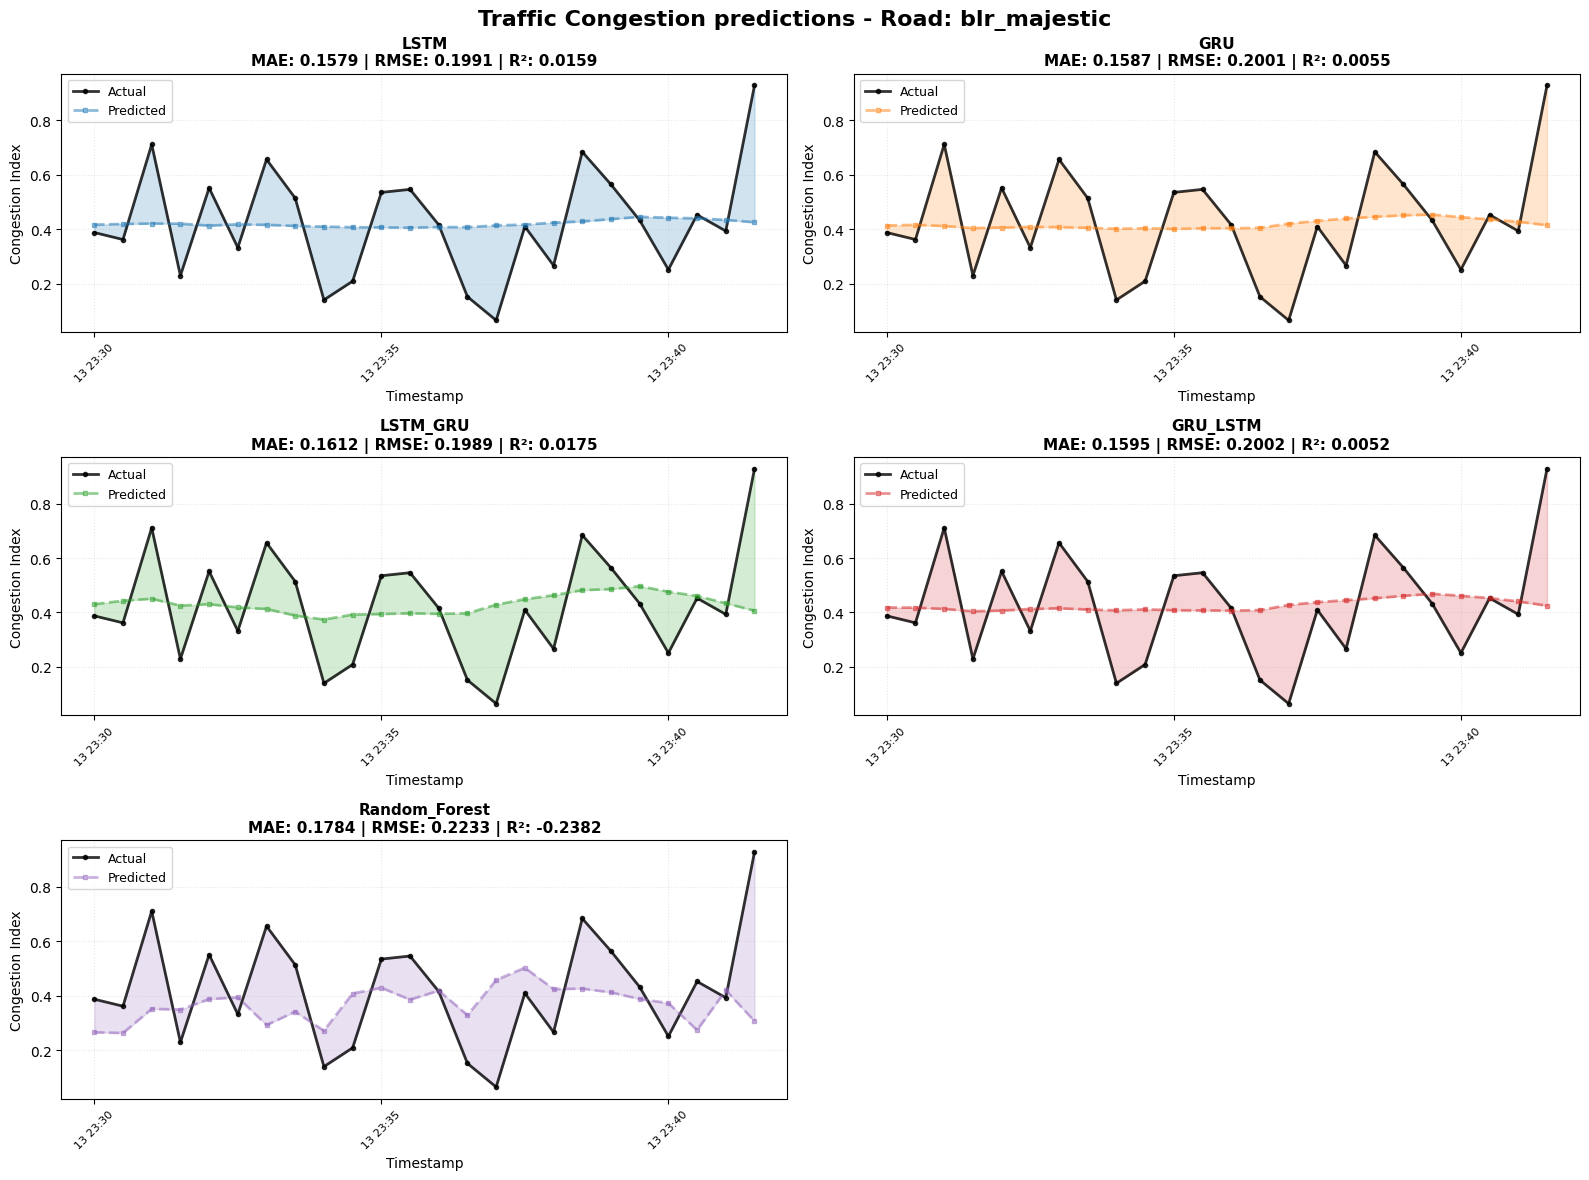


PREDICTIONS FOR NEXT 5 MINUTES
Filtered to road_id: blr_majestic, 124 records
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

LSTM:
  road_id: blr_majestic
  model: LSTM
  predicted_timestamp: 2025-10-13 23:46:30
  predicted_congestion_index: 0.41733604669570923
  current_congestion_index: 0.5020000000000001
  current_speed: 23.084999999999997
  last_update: 2025-10-13 23:41:30
Filtered to road_id: blr_majestic, 124 records
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step

GRU:
  road_id: blr_majestic
  model: GRU
  predicted_timestamp: 2025-10-13 23:46:30
  predicted_congestion_index: 0.4077591598033905
  current_congestion_index: 0.5020000000000001
  current_speed: 23.084999999999997
  last_update: 2025-10-13 23:41:30
Filtered to road_id: blr_majestic, 124 records
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

LSTM_GRU:
  road_id: blr_majestic
  model: LSTM_GRU
  predicted_timestamp: 2025-10-13 23:46:30
  predicted_congestion_index: 0.3754342198371887
  current_congestion_index: 0.5020000000000001
  current_sp

In [28]:
import os
import pandas as pd

if __name__ == "__main__":
    # Initialize predictor
    predictor = RealtimeTrafficPredictor(
        data_path='../data/gold',
        model_path='../src/models/'
    )

    # Load all parquet files from the data directory
    parquet_dir = '../data/gold'
    all_dfs = []

    for file in os.listdir(parquet_dir):
        if file.endswith('.parquet'):
            file_path = os.path.join(parquet_dir, file)
            print(f"Loading {file_path} ...")
            df = predictor.load_data(file)  # use your method
            all_dfs.append(df)

    # Merge all dataframes into one
    full_df = pd.concat(all_dfs, ignore_index=True)
    print(f"\nTotal records after merging: {len(full_df)}")

    # Train all models for a specific road
    road_id = 'blr_majestic'  # Replace with your road_id
    results, predictions = predictor.train_all_models(full_df, road_id=road_id)

    # Predict next 5 minutes using different models
    print("\n" + "="*60)
    print("PREDICTIONS FOR NEXT 5 MINUTES")
    print("="*60)

    for model in ['LSTM', 'GRU', 'LSTM_GRU', 'GRU_LSTM', 'Random_Forest']:
        prediction = predictor.predict_next_5min(full_df, road_id, model_name=model)
        print(f"\n{model}:")
        for key, value in prediction.items():
            print(f"  {key}: {value}")
